# Análise de Tickets de Help Desk

Este notebook guia a análise completa de um dataset de chamados de TI.

# Passos do projeto

1. Passo 1: Exploração inicial dos dados
2. Passo 2: Limpeza dos dados
3. Passo 3: Análise e agregações de negócio
4. Passo 4: Visualizações com gráficos
5. passo 5: Conclusão da análise

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

In [ ]:
csv_path = "customer_support_tickets.csv"

df = pd.read_csv(csv_path)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [ ]:
df.columns.tolist()

['Ticket ID',
 'Customer Name',
 'Customer Email',
 'Customer Age',
 'Customer Gender',
 'Product Purchased',
 'Date of Purchase',
 'Ticket Type',
 'Ticket Subject',
 'Ticket Description',
 'Ticket Status',
 'Resolution',
 'Ticket Priority',
 'Ticket Channel',
 'First Response Time',
 'Time to Resolution',
 'Customer Satisfaction Rating']

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   str           
 2   Customer Email                8469 non-null   str           
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   str           
 5   Product Purchased             8469 non-null   str           
 6   Date of Purchase              8469 non-null   datetime64[us]
 7   Ticket Type                   8469 non-null   str           
 8   Ticket Subject                8469 non-null   str           
 9   Ticket Description            8469 non-null   str           
 10  Ticket Status                 8469 non-null   str           
 11  Resolution                    2769 non-nu

In [ ]:
df.isna().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Analisando os dados, muitos dados estão sem resolução e a formatação de alguns está errada e muitos compos com datas estão em string.

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64


In [ ]:
print(df["Ticket Channel"].value_counts())

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


Convertendo as datas para datetime

In [ ]:
df["Date of Purchase"] = pd.to_datetime(df["Date of Purchase"], errors="coerce")
df["First Response Time"] = pd.to_datetime(df["First Response Time"], errors="coerce")
df["Time to Resolution"] = pd.to_datetime(df["Time to Resolution"], errors="coerce")

Analisando prioridade e quantidade de chamados fechados

In [ ]:
closed_mask = df["Ticket Status"].str.lower().str.contains("closed", na=False)
total_por_prioridade = df.groupby("Ticket Priority").size()
fechados_por_prioridade = df[closed_mask].groupby("Ticket Priority").size()
abertos_por_prioridade = total_por_prioridade - fechados_por_prioridade

resultado = (
    pd.DataFrame(
        {"Total": total_por_prioridade, "Fechados": fechados_por_prioridade, "Abertos": abertos_por_prioridade}
    )
    .fillna(0)
    .astype(int)
)

resultado["percentual_fechados"] = (resultado["Fechados"] / resultado["Total"] * 100).round(1)
print(resultado.sort_values("Total", ascending=False))

                 Total  Fechados  Abertos  percentual_fechados
Ticket Priority                                               
Medium            2192       694     1498                 31.7
Critical          2129       726     1403                 34.1
High              2085       705     1380                 33.8
Low               2063       644     1419                 31.2


Tempo de resolução por prioridade

In [ ]:
fechados = df[df["Ticket Status"].str.lower() == "closed"].copy()
fechados["Resolution Duration"] = fechados["Time to Resolution"] - fechados["First Response Time"]

media_minutos = (fechados.groupby("Ticket Priority")["Resolution Duration"].mean().dt.total_seconds() / 60).round(1)

for prioridade, minutos in media_minutos.items():
    print(f"Tempo médio para resolução {prioridade}: {minutos:.1f} minutos")

Tempo médio para resolução Critical: 428.8 minutos
Tempo médio para resolução High: 484.5 minutos
Tempo médio para resolução Low: 476.8 minutos
Tempo médio para resolução Medium: 430.3 minutos


Tipos de probelmas que mais aparecem

In [ ]:
df["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

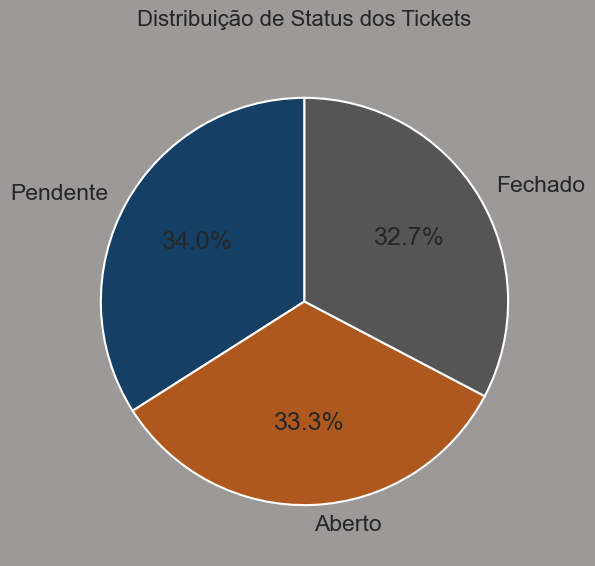

In [ ]:
ticket_status = df["Ticket Status"].value_counts()

mapeamento = {"Closed": "Fechado", "Open": "Aberto", "Pending Customer Response": "Pendente"}
labels_abreviados = [mapeamento.get(label, label) for label in ticket_status.index]

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#9c9999")
ax.pie(
    ticket_status.values,
    labels=labels_abreviados,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#153F64", "#AF581E", "#555555"],
)

ax.set_title("Distribuição de Status dos Tickets", fontsize=16, pad=15)
plt.tight_layout()
plt.show()

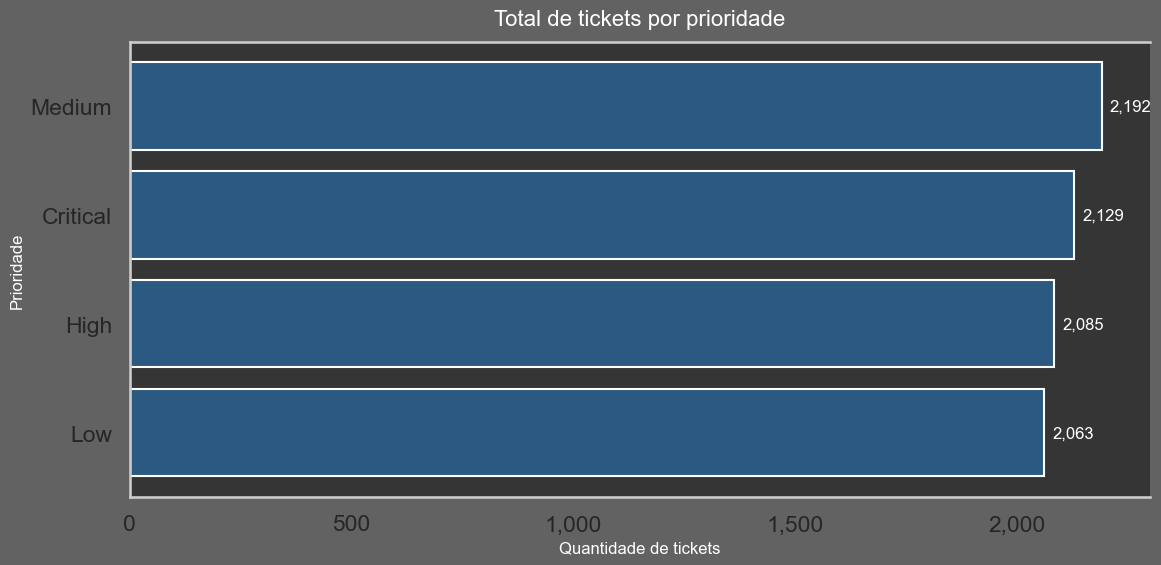

In [ ]:
resultado_plot = resultado.sort_values("Total", ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#636262")
ax.set_facecolor("#353535")


bars = ax.barh(resultado_plot.index, resultado_plot["Total"], color="#2C5981")

# rótulos à direita de cada barra (com separador de milhares)
for bar in bars:
    width = int(bar.get_width())
    ax.annotate(
        f"{width:,}",
        xy=(bar.get_x() + bar.get_width(), bar.get_y() + bar.get_height() / 2),
        xytext=(6, 0),  # deslocamento em pontos para a direita
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=12,
        color="#FFFFFF",
    )
    ax.grid(False)
    ax.spines["right"].set_visible(False)


ax.set_title("Total de tickets por prioridade", fontsize=16, pad=12, color="#ffffff")
ax.set_xlabel("Quantidade de tickets", fontsize=12, color="#ffffff")
ax.set_ylabel("Prioridade", fontsize=12, color="#ffffff")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

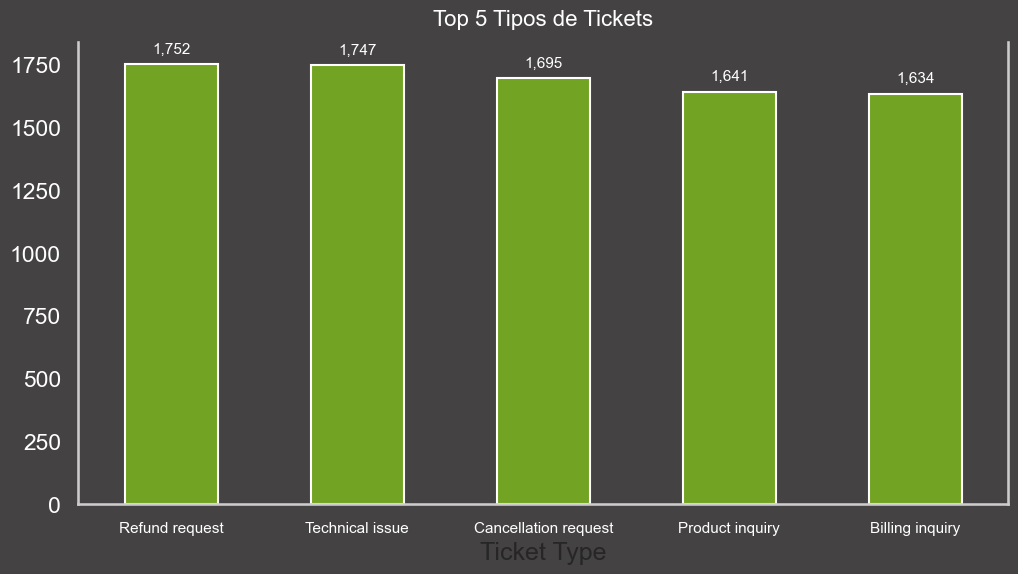

<Figure size 640x480 with 0 Axes>

In [ ]:
ticket_type = df["Ticket Type"].value_counts().head(5)
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#444242")
ax.set_facecolor("#444242")

ticket_type.plot(kind="bar", ax=ax, color="#72A322")

for bar in ax.patches:
    height = int(bar.get_height())

    ax.annotate(
        f"{height:,}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#FFFFFF",
    )
ax.tick_params(axis="x", colors="#ffffff")
ax.tick_params(axis="y", colors="#ffffff")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
ax.set_title("Top 5 Tipos de Tickets", fontsize=16, pad=12, color="#ffffff")
plt.show()
plt.tight_layout()

# Conclusões da análise

## Descobertas Principais

### 1. **Distribuição de Status dos Tickets**
- **32.7%** dos tickets foram **Fechados** com sucesso
- **33.3%** estão **Abertos** e aguardando resolução
- **34.0%** estão **Pendentes** aguardando resposta do cliente

**Insight**: Apenas 1/3 dos tickets foi resolvido. Oportunidade para melhorar taxa de resolução.

---

### 2. **Volume Equilibrado por Prioridade**
- Taxa de fechamento: ~31-34% para todas as prioridades
- Tickets críticos não têm tratamento diferenciado

**Insight**: Prioridade não influencia tempo de resolução. Revisar critérios de SLA.

---

### 3. **Tempo de Resolução Consistente**
- Critical: 428.8 minutos (7.1 horas) - MAIS RÁPIDO
- Medium: 430.3 minutos (7.2 horas)
- High: 484.5 minutos (8.1 horas)
- Low: 476.8 minutos (7.9 horas)

---

### 4. **Tipos de Problemas Mais Frequentes**
1. Refund Request: 1.752 (24.9%)
2. Technical Issue: 1.747 (24.8%)
3. Cancellation Request: 1.695 (24.1%)

**75% dos tickets** são sobre reembolsos, técnico ou cancelamentos.

---

### 5. **Canais Equilibrados**
Email, Phone, Social Media e Chat distribuem uniformemente o volume (~30% cada).

---

##  Recomendações

-  Aumentar taxa de resolução de 32.7% para 50%+
-  Reduzir tempo de resolução para 4 horas
-  Criar base de conhecimento para top 3 problemas